<a href="https://colab.research.google.com/github/TiferetChayahShalom/DI_Bootcamp/blob/main/Week%209/Day%203/Daily%20Challenge/Pokemon_Data_Analysis_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import zipfile
import os

zip_path = "/content/Pokemon Data Analysis Tutorial.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
  zip_ref.extractall("/content/pokemon_data")

print(os.listdir("/content/pokemon_data"))

['Pokemon Data Analysis Tutorial']


In [23]:
folder = "/content/pokemon_data/Pokemon Data Analysis Tutorial"

print(os.listdir(folder))

['tests.csv', 'combats.csv', 'pokemon.csv']


In [24]:
import pandas as pd

pokemon = pd.read_csv(folder + "/pokemon.csv")
combats = pd.read_csv(folder + "/combats.csv")

print("Pokemon shape:", pokemon.shape)
print("Combats shape:", combats.shape)

display(pokemon.head())
display(combats.head())

Pokemon shape: (800, 12)
Combats shape: (50000, 3)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [25]:
# Check missing values first
print("Missing values BEFORE cleaning:")
print(pokemon.isnull().sum())

# Fix the missing Name for Pokemon #62
pokemon.loc[pokemon["#"] == 62, "Name"] = "Primeape"

# Replace missing Type 2 with "None"
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

# Check again
print("\nMissing values AFTER cleaning:")
print(pokemon.isnull().sum())

# Display Pokemon #62 to confirm
display(pokemon[pokemon["#"] == 62])

Missing values BEFORE cleaning:
#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Missing values AFTER cleaning:
#             0
Name          1
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
61,62,Primeape,Fighting,None,40,80,35,35,45,70,1,False


In [26]:
# Find the Pokemon that still has a missing Name
pokemon[pokemon["Name"].isnull()]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,None,65,105,60,60,70,95,1,False


In [27]:
# Correct the Pokemon names
pokemon.loc[pokemon["#"] == 62, "Name"] = "Mankey"
pokemon.loc[pokemon["#"] == 63, "Name"] = "Primeape"

# Confirm the correction
display(pokemon[pokemon["#"].isin([62, 63])])

# Check missing values
print("\nMissing values:")
print(pokemon.isnull().sum())

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
61,62,Mankey,Fighting,None,40,80,35,35,45,70,1,False
62,63,Primeape,Fighting,None,65,105,60,60,70,95,1,False



Missing values:
#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [28]:
# Count how many battles each Pokemon participated in
first_counts = combats["First_pokemon"].value_counts()
second_counts = combats["Second_pokemon"].value_counts()

total_battles = first_counts.add(second_counts, fill_value=0)

# Count how many battles each Pokemon won
wins = combats["Winner"].value_counts()

# Calculate win percentage
win_percentage = (wins / total_battles * 100).fillna(0)

# Add win percentage to the Pokemon dataframe
pokemon["Win Percentage"] = pokemon["#"].map(win_percentage).fillna(0)

# Show the result
display(
    pokemon[["#", "Name", "HP", "Attack", "Defense", "Speed", "Win Percentage"]].head(10)

)

,#,Name,HP,Attack,Defense,Speed,Win Percentage
0,1,Bulbasaur,45,49,49,45,27.819549
1,2,Ivysaur,60,62,63,60,38.016529
2,3,Venusaur,80,82,83,80,67.424242
3,4,Mega Venusaur,80,100,123,80,56.000000
4,5,Charmander,39,52,43,65,49.107143
5,6,Charmeleon,58,64,58,80,54.237288
6,7,Charizard,78,84,78,100,86.466165
7,8,Mega Charizard X,78,130,111,100,85.611511
8,9,Mega Charizard Y,78,104,78,100,84.444444
9,10,Squirtle,44,48,65,43,16.239316


                      HP    Attack     Speed  Win Percentage
HP              1.000000  0.422386  0.175952        0.234889
Attack          0.422386  1.000000  0.381240        0.476675
Speed           0.175952  0.381240  1.000000        0.905409
Win Percentage  0.234889  0.476675  0.905409        1.000000


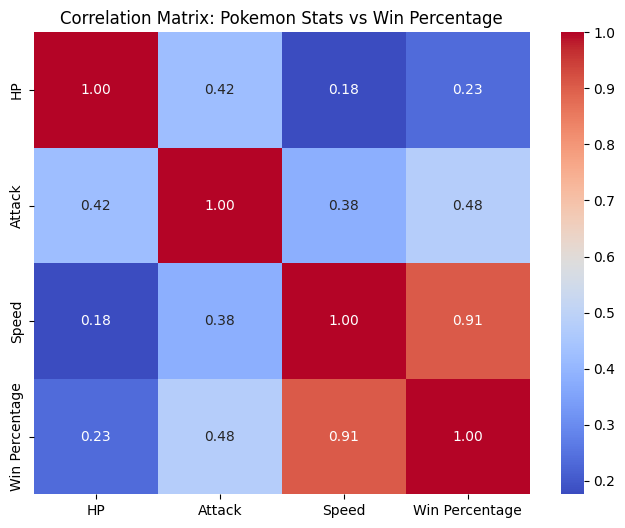

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the required variables
correlation_data = pokemon[
    ["HP", "Attack", "Speed", "Win Percentage"]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

print(correlation_matrix)

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix: Pokemon Stats vs Win Percentage")
plt.show()


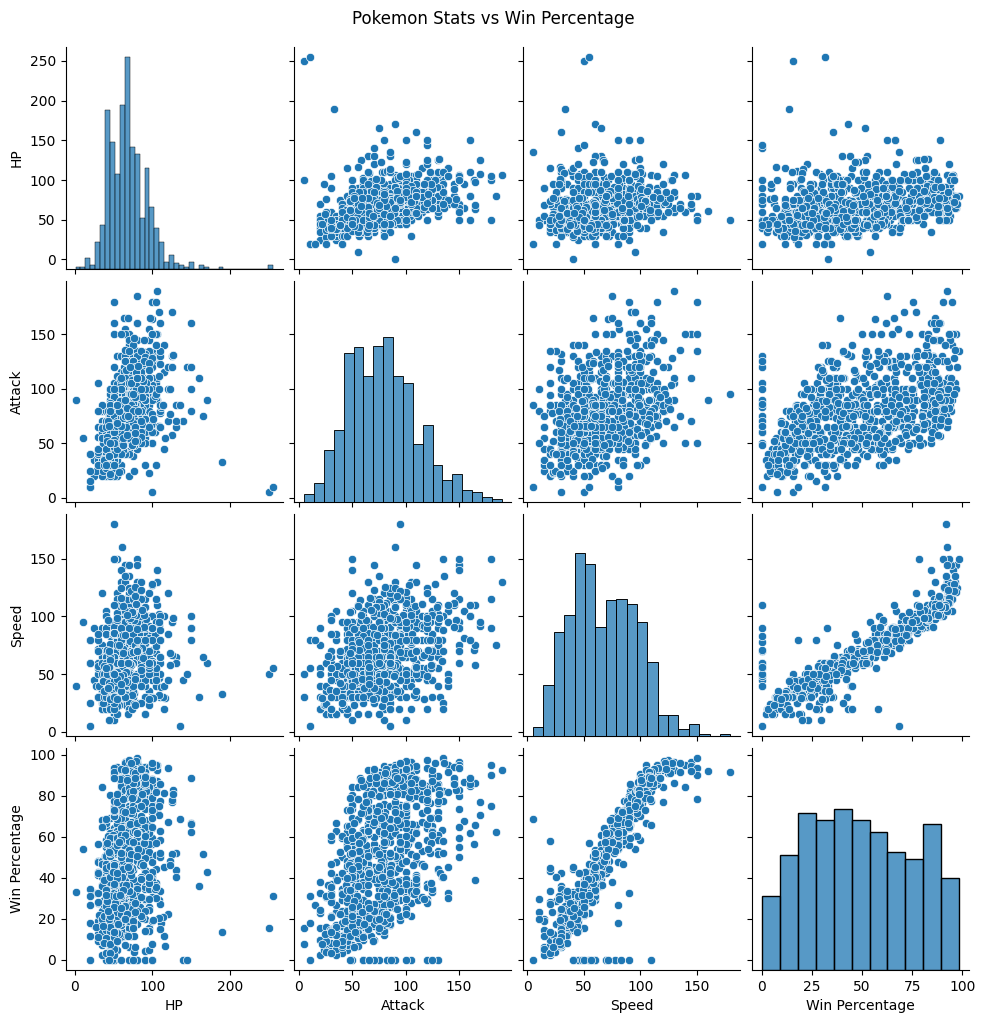

In [30]:
# Pairplot: Pokemon stats vs Win Percentage

pairplot_data = pokemon[
    ["HP", "Attack", "Speed", "Win Percentage"]
]

sns.pairplot(pairplot_data)

plt.suptitle(
    "Pokemon Stats vs Win Percentage",
    y=1.02
)

plt.show()

In [31]:
# Top 10 Pokemon by Win Percentage

top_10 = pokemon.sort_values(
    by="Win Percentage",
    ascending=False
).head(10)

top_10_stats = top_10[
    ["#", "Name", "HP", "Attack", "Defense", "Speed", "Win Percentage"]
]

display(top_10_stats)

,#,Name,HP,Attack,Defense,Speed,Win Percentage
154,155,Mega Aerodactyl,80,135,85,150,98.449612
512,513,Weavile,70,120,65,125,97.478992
703,704,Tornadus Therian Forme,79,100,80,121,96.800000
19,20,Mega Beedrill,65,150,40,145,96.638655
153,154,Aerodactyl,80,105,65,130,96.453901
476,477,Mega Lopunny,65,136,94,135,96.124031
726,727,Greninja,72,95,67,122,96.062992
716,717,Meloetta Pirouette Forme,100,128,90,128,95.934959
164,165,Mega Mewtwo Y,106,150,70,140,95.200000
349,350,Mega Sharpedo,70,140,70,105,95.000000


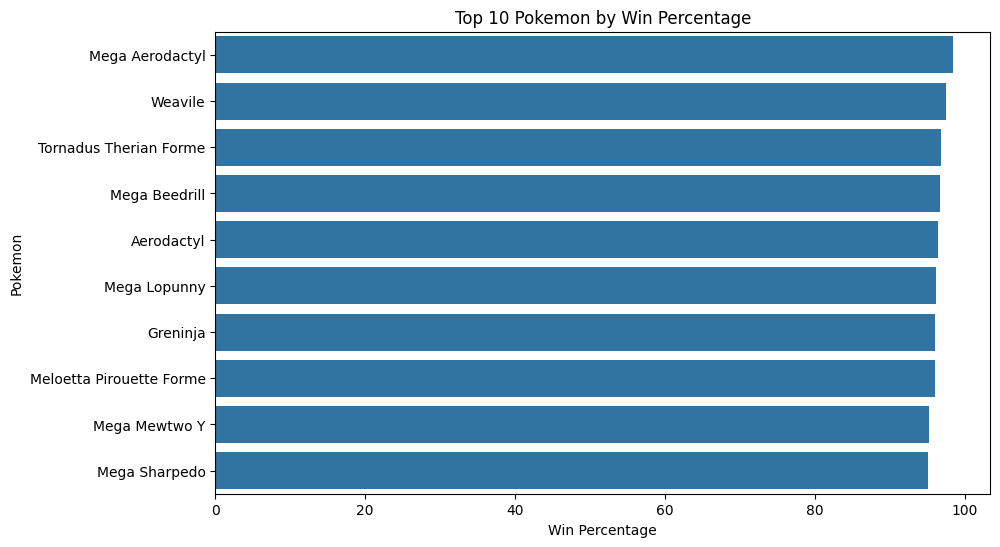

In [32]:
#make graph
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_stats,
    x="Win Percentage",
    y="Name"
)

plt.title("Top 10 Pokemon by Win Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("Pokemon")

plt.show()

Top 10 Pokémon Analysis:

The top 10 Pokémon by win percentage generally have strong battle statistics. Speed appears to be particularly important because faster Pokémon can gain an advantage during battles. Attack and other combat statistics may also contribute to higher win percentages.

In [33]:
# MACHINE LEARNING
# Step 1: Prepare features and split the data

from sklearn.model_selection import train_test_split

# Features used to predict Win Percentage
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

X = pokemon[features]
y = pokemon["Win Percentage"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (640, 6)
Testing data: (160, 6)


In [34]:
# Model 1: Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
linear_predictions = linear_model.predict(X_test)

# Calculate MAE
linear_mae = mean_absolute_error(y_test, linear_predictions)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 6.491538345586539


In [35]:
# Model 2: Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

# Create and train the model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest_model.predict(X_test)

# Calculate MAE
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 5.749736722585777


In [36]:
# Model 3: Gradient Boosting Regression

from sklearn.ensemble import GradientBoostingRegressor

# Create and train model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
gb_predictions = gb_model.predict(X_test)

# Calculate MAE
gb_mae = mean_absolute_error(y_test, gb_predictions)

print("Gradient Boosting MAE:", gb_mae)

Gradient Boosting MAE: 5.594083758885463


,Model,MAE
2,Gradient Boosting,5.594084
1,Random Forest,5.749737
0,Linear Regression,6.491538


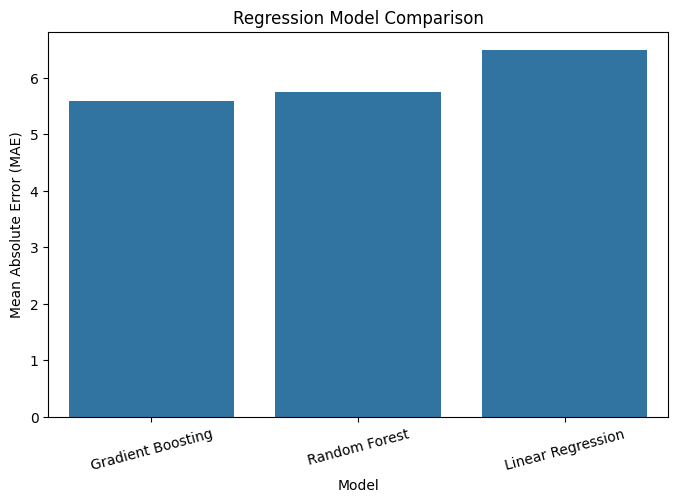

In [37]:
# Compare the three regression models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
        ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
        ]
})

results = results.sort_values("MAE")

display(results)

# Plot model comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Regression Model Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xticks(rotation=15)

plt.show()

Conclusion:
Three machine-learning regression models were compared to predict Pokémon win percentage: Linear Regression, Random Forest, and Gradient Boosting.
Gradient Boosting achieved the lowest Mean Absolute Error (MAE) of approximately 5.59, followed by Random Forest at 5.75 and Linear Regression at 6.49.
Therefore, Gradient Boosting is the best-performing model because it produced the smallest prediction error.